# ¿Hace falta entrenar el encoder con JEPA?

Este notebook es una **comparación exploratoria sobre validation con una sola seed**. Compara siete métodos sobre la misma familia $K_\rho=\rho C$ y las mismas ventanas. Sirve para establecer si JEPA es necesario en este dataset; no es una comparación confirmatoria multiseed.

La métrica principal es el MAE de la estimación espectral continua de $\rho$. La clasificación entre cinco candidatos queda como diagnóstico secundario.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Markdown, display

from koopman_jepa.analysis import calibration_statistics
from koopman_jepa.decay_benchmark import BASELINE_METHODS, run_decay_baseline_development
from koopman_jepa.phase_data import PhaseWindowConfig, make_decay_phase_tensor_dataset_splits

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
CONFIG_PATH = ROOT / 'configs' / 'koopman_decay_baselines.yaml'
with CONFIG_PATH.open(encoding='utf-8') as handle:
    raw = yaml.safe_load(handle)

rhos = tuple(float(rho) for rho in raw['rho_values'])
development_seed = int(raw['seeds'][0])
invalid_error = float(raw['evaluation']['invalid_active_span_absolute_error'])
assert raw['status'] == 'completed_validation_only'
assert tuple(raw['methods']) == BASELINE_METHODS
assert raw['splits']['heldout_access'] == 'after_methods_tests_and_config_are_frozen'
display(Markdown(f'**Config:** `{CONFIG_PATH.name}` · **seed de desarrollo:** `{development_seed}` · **held-out:** cerrado'))

**Config:** `koopman_decay_baselines.yaml` · **seed de desarrollo:** `101` · **held-out:** cerrado

## Qué separa cada baseline

| Método | Pregunta que responde |
|---|---|
| Oracle de fase | ¿La estimación y la evaluación matemática funcionan? |
| DMD crudo | ¿La dinámica ya es lineal en las ventanas? |
| PCA-3 + DMD | ¿Basta una compresión lineal del tamaño del latent? |
| CNN aleatoria + DMD | ¿La arquitectura sin entrenamiento ya produce features suficientes? |
| CNN supervisada + DMD | ¿Qué logra el mismo encoder si recibe la fase explícitamente? |
| JEPA + predictor aprendido | Método bajo estudio. |
| JEPA + DMD post-hoc | ¿El encoder es mejor que el predictor aprendido? |

PCA, CNN aleatoria y CNN supervisada se ajustan una sola vez para esta seed. JEPA se entrena por separado para cada $\rho$, porque sus pares temporales cambian.

In [3]:
emission = PhaseWindowConfig(**raw['emission'], repeats_per_transition=1)
splits = make_decay_phase_tensor_dataset_splits(
    emission,
    rhos,
    train_repeats_per_transition=raw['splits']['train_repeats_per_transition'],
    validation_repeats_per_transition=raw['splits']['validation_repeats_per_transition'],
    seed=development_seed,
)
assert splits.heldout is None and splits.heldout_seed is None
benchmark = run_decay_baseline_development(raw, splits, seed=development_seed)
rows = list(benchmark.rows)
assert len(rows) == len(BASELINE_METHODS) * len(rhos)
print(f'Corridas evaluadas: {len(rows)}; held-out materializado: {splits.heldout is not None}')

epoch=001 train=3.715072 val=2.652702


epoch=012 train=1.865752 val=2.220226


epoch=024 train=1.775678 val=2.114241


epoch=036 train=1.739629 val=2.091506


epoch=048 train=1.739016 val=2.087865


...

epoch=012 train=1.494119 val=2.291451


epoch=024 train=1.222429 val=2.017044


epoch=036 train=1.047782 val=1.852093


epoch=048 train=0.956590 val=1.757465


epoch=060 train=0.906435 val=1.705669
Corridas evaluadas: 35; held-out materializado: False


## Resultado de validation

Cada fila resume los cinco valores de $\rho$ para un método. `Rango 3` indica en cuántas condiciones existe el subespacio espectral requerido. Un rango inválido no se descarta: aporta el error predeclarado `1.0` al MAE espectral.

In [4]:
summary = {}
for method in BASELINE_METHODS:
    subset = sorted((row for row in rows if row['method'] == method), key=lambda row: row['rho'])
    truth = np.array([row['rho'] for row in subset], dtype=float)
    spectral = np.array([np.nan if row['spectral_rho_estimate'] is None else row['spectral_rho_estimate'] for row in subset], dtype=float)
    action = np.array([np.nan if row['action_rho_estimate'] is None else row['action_rho_estimate'] for row in subset], dtype=float)
    spectral_stats = calibration_statistics(truth, spectral, invalid_absolute_error=invalid_error)
    action_stats = calibration_statistics(truth, action, invalid_absolute_error=invalid_error)
    summary[method] = {
        'spectral_mae': spectral_stats['mae'],
        'action_mae': action_stats['mae'],
        'slope': spectral_stats['slope'],
        'r_squared': spectral_stats['r_squared'],
        'rank3': sum(row['active_rank'] == raw['evaluation']['active_rank_required_for_spectrum'] for row in subset),
        'median_action_error': float(np.median([row['true_action_error'] for row in subset])),
        'median_h8_error': float(np.median([row['rollout_errors'][8] for row in subset])),
    }

lines = [
    '| Método | MAE espectral | MAE acción | Pendiente | $R^2$ | Rango 3 | Error acción | Rollout $h=8$ |',
    '|---|---:|---:|---:|---:|---:|---:|---:|',
]
for method in BASELINE_METHODS:
    item = summary[method]
    slope = '—' if item['slope'] is None else f"{item['slope']:.3f}"
    r_squared = '—' if item['r_squared'] is None else f"{item['r_squared']:.3f}"
    lines.append(f"| `{method}` | {item['spectral_mae']:.3f} | {item['action_mae']:.3f} | {slope} | {r_squared} | {item['rank3']}/5 | {item['median_action_error']:.3f} | {item['median_h8_error']:.3f} |")
display(Markdown('\n'.join(lines)))

| Método | MAE espectral | MAE acción | Pendiente | $R^2$ | Rango 3 | Error acción | Rollout $h=8$ |
|---|---:|---:|---:|---:|---:|---:|---:|
| `phase_oracle_ols` | 0.000 | 0.000 | 1.000 | 1.000 | 5/5 | 0.000 | 0.000 |
| `raw_window_dmd` | 0.022 | 0.020 | 0.949 | 1.000 | 5/5 | 0.036 | 0.001 |
| `pca3_dmd` | 0.011 | 0.011 | 0.975 | 1.000 | 5/5 | 0.021 | 0.000 |
| `random_cnn3_dmd` | 0.299 | 0.137 | 0.391 | 0.999 | 5/5 | 0.182 | 0.004 |
| `supervised_phase_cnn3_dmd` | 0.012 | 0.011 | 0.968 | 1.000 | 5/5 | 0.018 | 0.001 |
| `jepa_learned_predictor` | 0.197 | 0.103 | 0.435 | 0.799 | 5/5 | 0.141 | 0.022 |
| `jepa_posthoc_dmd` | 0.029 | 0.026 | 0.952 | 0.999 | 5/5 | 0.028 | 0.001 |

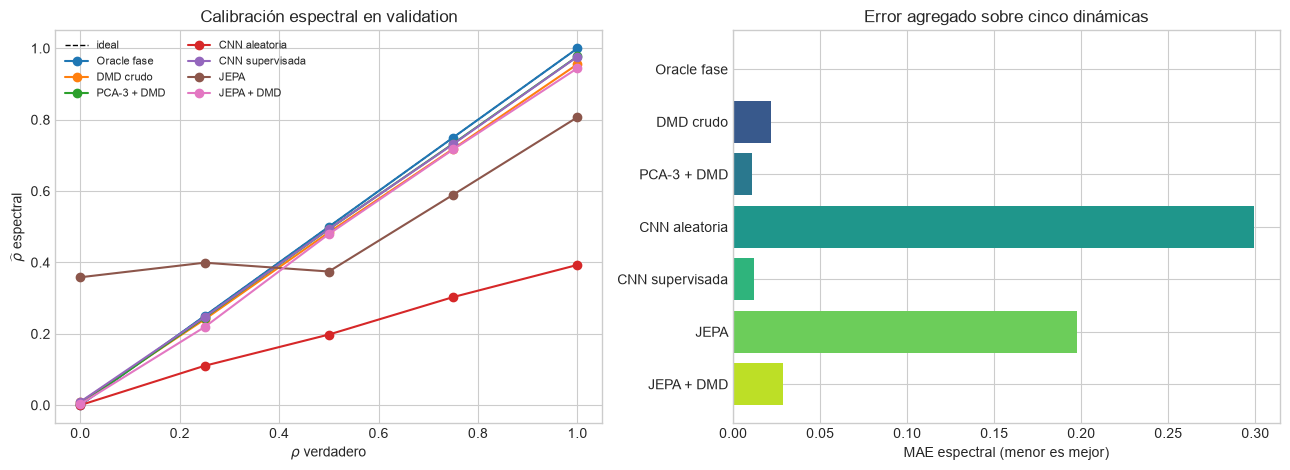

In [5]:
labels = {
    'phase_oracle_ols': 'Oracle fase',
    'raw_window_dmd': 'DMD crudo',
    'pca3_dmd': 'PCA-3 + DMD',
    'random_cnn3_dmd': 'CNN aleatoria',
    'supervised_phase_cnn3_dmd': 'CNN supervisada',
    'jepa_learned_predictor': 'JEPA',
    'jepa_posthoc_dmd': 'JEPA + DMD',
}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot([0, 1], [0, 1], '--', color='black', linewidth=1, label='ideal')
for method in BASELINE_METHODS:
    subset = sorted((row for row in rows if row['method'] == method), key=lambda row: row['rho'])
    estimates = [row['spectral_rho_estimate'] for row in subset]
    axes[0].plot(rhos, estimates, marker='o', label=labels[method])
axes[0].set(xlabel=r'$\rho$ verdadero', ylabel=r'$\widehat{\rho}$ espectral', title='Calibración espectral en validation')
axes[0].legend(fontsize=8, ncol=2)

maes = [summary[method]['spectral_mae'] for method in BASELINE_METHODS]
axes[1].barh([labels[method] for method in BASELINE_METHODS], maes, color=plt.cm.viridis(np.linspace(0.15, 0.9, len(maes))))
axes[1].invert_yaxis()
axes[1].set(xlabel='MAE espectral (menor es mejor)', title='Error agregado sobre cinco dinámicas')
fig.tight_layout()
display(fig)
plt.close(fig)

In [6]:
jepa_mae = summary['jepa_learned_predictor']['spectral_mae']
random_mae = summary['random_cnn3_dmd']['spectral_mae']
raw_mae = summary['raw_window_dmd']['spectral_mae']
posthoc_mae = summary['jepa_posthoc_dmd']['spectral_mae']
supervised_mae = summary['supervised_phase_cnn3_dmd']['spectral_mae']
best_unsupervised = min(('raw_window_dmd', 'pca3_dmd', 'random_cnn3_dmd'), key=lambda method: summary[method]['spectral_mae'])

if jepa_mae < random_mae:
    causal_read = f"En esta seed, JEPA mejora a la CNN aleatoria en {random_mae - jepa_mae:.3f} puntos de MAE."
else:
    causal_read = f"En esta seed, la CNN aleatoria iguala o mejora a JEPA por {jepa_mae - random_mae:.3f} puntos de MAE; todavía no hay atribución a JEPA."
predictor_read = (
    f"El DMD post-hoc mejora al predictor JEPA por {jepa_mae - posthoc_mae:.3f} puntos, lo que señala margen en la optimización de M."
    if posthoc_mae < jepa_mae
    else f"El predictor aprendido no queda por debajo del DMD post-hoc en esta seed (diferencia {posthoc_mae - jepa_mae:.3f})."
)
display(Markdown(
    '## Lectura provisional\n\n'
    + causal_read + '\n\n'
    + f"El mejor baseline no supervisado aquí es `{best_unsupervised}`. DMD crudo obtiene MAE {raw_mae:.3f}; el techo supervisado, {supervised_mae:.3f}.\n\n"
    + predictor_read + '\n\n'
    + '**Alcance:** es una sola seed de validation. No ejecutamos la comparación confirmatoria multiseed ni abrimos el held-out.'
))

## Lectura provisional

En esta seed, JEPA mejora a la CNN aleatoria en 0.102 puntos de MAE.

El mejor baseline no supervisado aquí es `pca3_dmd`. DMD crudo obtiene MAE 0.022; el techo supervisado, 0.012.

El DMD post-hoc mejora al predictor JEPA por 0.169 puntos, lo que señala margen en la optimización de M.

**Alcance:** es una sola seed de validation. No ejecutamos la comparación confirmatoria multiseed ni abrimos el held-out.

## Decisión de cierre

El repositorio se cierra con esta comparación como evidencia exploratoria. No se materializó el held-out: por lo tanto, no afirmamos que JEPA supere estadísticamente a los baselines. El resultado principal queda acotado a demostrar aprendizaje del operador bajo los datos y supuestos documentados.